# CBPI stack の描画

以下の breakdown により CBPI stack を描画

- Kink 考慮（ベースライン）
- Kink 無視
- パス無視
- 魔法状態側のオペランド無視

## セットアップ

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.size"] = 14
pd.options.display.float_format = "{:.3f}".format

## 読み込み

In [3]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)


def load_table(table_path: str):
    df = pd.read_csv(table_path, sep="|")
    df = df.rename(columns={c: c.strip() for c in df.columns})
    circuit_names = df[""].str.strip()
    # circuit_names = df[""].str.replace("result_SELECT_", "")
    df = df.drop(columns=[""])
    df = df.astype(float)
    return circuit_names, df

## 描画

In [4]:
methods: list[str] = ["Single", "Double", "Proj"]

breakdown: list[str] = ["No MSF", "No Top", "No Kink", "Yes Kink"]
stack_labels: list[str] = ["Base", "Magic", "Path", "Kink"]

options: list[str] = [
    "1 outer SA",
    "1 inner SA",
    "2 outer SA",
    "2 inner SA",
]

In [5]:
from typing import Any


def draw(ax: Any, cbpi: pd.Series, option: str) -> None:
    bottom = np.zeros(len(methods))
    for bd, sl in zip(breakdown, stack_labels):
        method_height = bottom.copy()
        for i, method in enumerate(methods):
            name = f"{method} {bd} ({option})"
            if name in cbpi:
                method_height[i] = cbpi[name]
        method_height = np.array(method_height)
        # print(bd, method_height)
        if np.any(bottom > method_height):
            print(
                "Decreasing:",
                option,
                bd,
                np.array(methods)[bottom > method_height],
                np.max(bottom - method_height),
            )
            assert np.max(bottom - method_height) <= 10**-3  # 減少幅は微小なはず
            method_height = np.maximum(method_height, bottom)
        ax.bar(methods, method_height - bottom, 0.5, label=sl, bottom=bottom)
        ax.tick_params(axis="x", labelsize=12)
        bottom = method_height


def plot_all(
    circuit_names: pd.Series,
    cbpi_df: pd.DataFrame,
    save: bool,
    save_dir: str,
    save_name: str = "all.png",
) -> None:
    fig, axes = plt.subplots(
        len(circuit_names),
        len(options),
        figsize=(2 * len(options) + 2, 2 * len(circuit_names)),
        sharex=True,
        sharey=True,
    )

    for i, cbpi in cbpi_df.iterrows():
        for j, option in enumerate(options):
            draw(axes[i, j], cbpi, option)

    for i, circuit in enumerate(circuit_names):
        axes[i, 0].set_ylabel(
            circuit.replace("result_SELECT_", ""), fontsize=8, rotation=0, labelpad=75
        )
    for j, option in enumerate(options):
        axes[-1, j].set_xlabel(option)

    handles, labels = axes[0, -1].get_legend_handles_labels()
    axes[0, -1].legend(
        handles=handles[::-1],
        labels=labels[::-1],
        bbox_to_anchor=(1.1, 1),
        loc="upper left",
        borderaxespad=0,
    )
    if save:
        plt.savefig(os.path.join(save_dir, save_name))
    plt.show()


def plot_group_wise(
    circuit_names: pd.Series, cbpi_df: pd.DataFrame, save: bool, save_dir: str
) -> None:
    # delete last "_\d.in"
    groups = circuit_names.str.slice(stop=-5)
    for group_name, indices in groups.groupby(groups).groups.items():
        print(group_name, indices)
        plot_all(
            circuit_names.iloc[indices].reset_index(drop=True),
            cbpi_df.iloc[indices].reset_index(drop=True),
            save,
            save_dir,
            group_name + "_grouped.png",
        )


def plot_circuit_wise(
    circuits: pd.Series,
    cbpi_df: pd.DataFrame,
    save: bool,
    save_dir: str,
) -> None:
    if save:
        os.makedirs(save_dir, exist_ok=True)

    for i, cbpi in cbpi_df.iterrows():
        circuit = circuits[i]
        fig, axes = plt.subplots(
            1,
            len(options),
            figsize=(2 * len(options) + 2, 3),
            sharex=True,
            sharey=True,
        )

        for j, option in enumerate(options):
            draw(axes[j], cbpi, option)

        fig.suptitle(circuit.replace("result_SELECT_", ""), fontsize=18)
        for j, option in enumerate(options):
            axes[j].set_xlabel(option)

        handles, labels = axes[-1].get_legend_handles_labels()
        axes[-1].legend(
            handles=handles[::-1],
            labels=labels[::-1],
            bbox_to_anchor=(1.1, 1),
            loc="upper left",
            borderaxespad=0,
        )

        plt.tight_layout()
        if save:
            figname = os.path.join(save_dir, circuit.replace(".in", ".png"))
            plt.savefig(figname)
        plt.show()


def plot_each(
    circuit_names: pd.Series, cbpi_df: pd.DataFrame, save: bool, save_dir: str
) -> None:
    for j, cbpi in cbpi_df.iterrows():
        circuit_name = circuit_names[j]
        print(circuit_name)
        for i, option in enumerate(options):
            fig, ax = plt.subplots()
            draw(ax, cbpi, option)
            ax.set_title(f"{option} {circuit_name}")
            ax.legend()
            plt.show()

In [6]:
def analyze(
    table_path: str, style: str, save: bool = False, save_dir="../../fig/cbpi_stack"
) -> None:
    circuit_names, code_beat_df = load_table(table_path)
    number_of_instructions = [get_number_of_instructions(c) for c in circuit_names]
    cbpi_df = code_beat_df.div(np.array(number_of_instructions), axis=0)
    if style == "each":
        plot_each(circuit_names, cbpi_df, save, save_dir)
    elif style == "group-wise":
        plot_group_wise(circuit_names, cbpi_df, save, save_dir)
    elif style == "circuit-wise":
        plot_circuit_wise(circuit_names, cbpi_df, save, save_dir)
    elif style == "all":
        plot_all(circuit_names, cbpi_df, save, save_dir)
    else:
        raise ValueError(f"Unknown option: {style = }")

## 実験

### All SELECT circuits

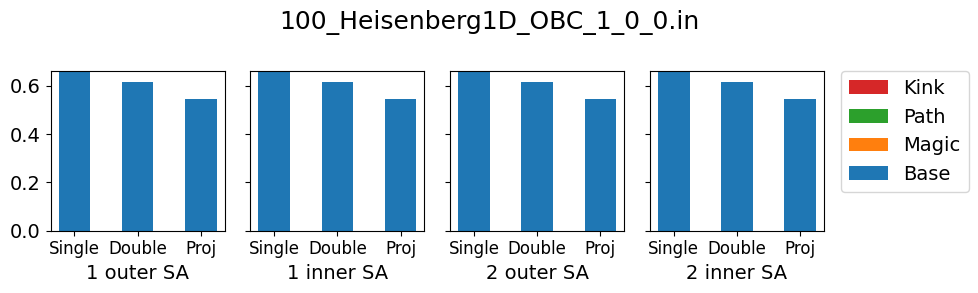

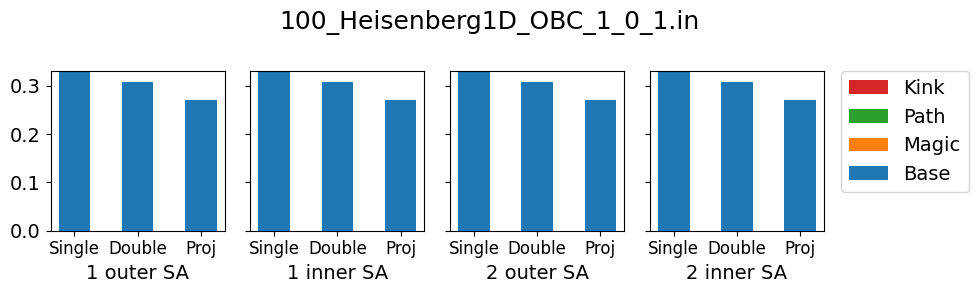

Decreasing: 1 outer SA Yes Kink ['Proj'] 7.48839299086479e-05


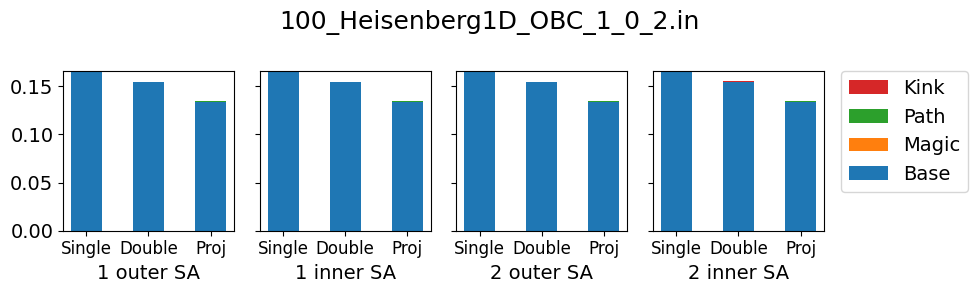

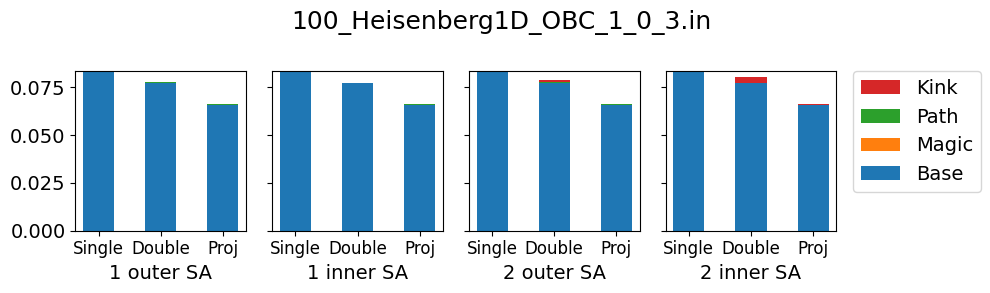

Decreasing: 1 outer SA Yes Kink ['Double'] 0.0005595188138201104


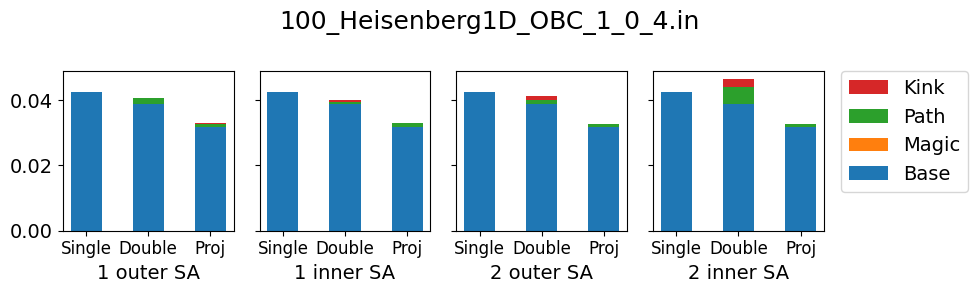

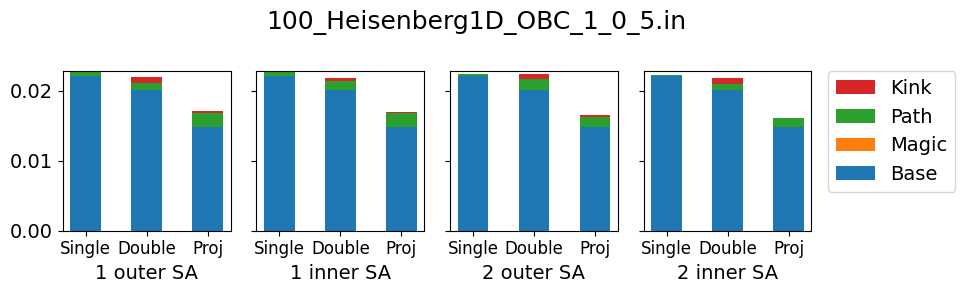

Decreasing: 2 outer SA Yes Kink ['Single'] 5.704506560182468e-05


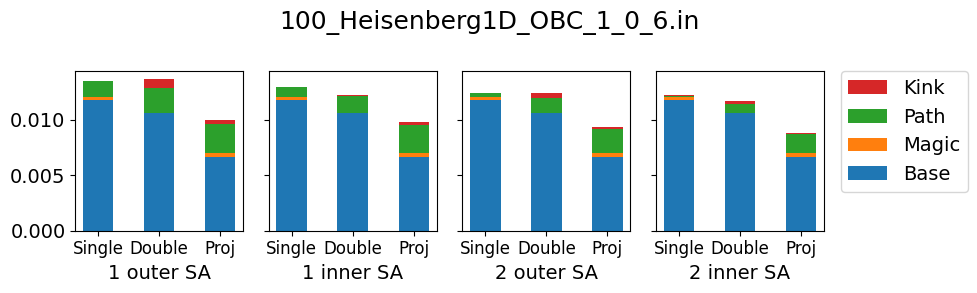

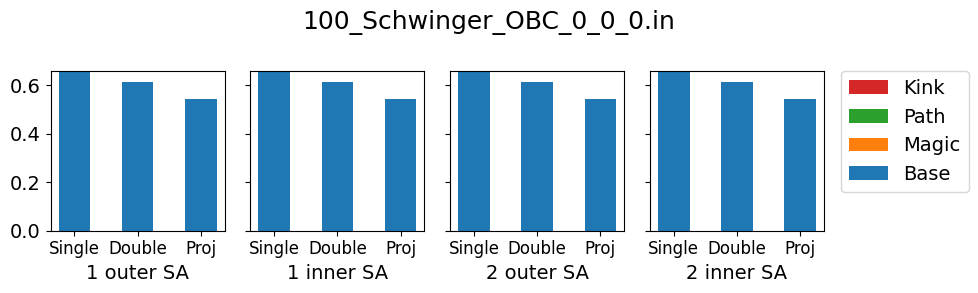

Decreasing: 1 outer SA Yes Kink ['Proj'] 1.7651315905586884e-05
Decreasing: 2 outer SA Yes Kink ['Proj'] 1.7651315905586884e-05


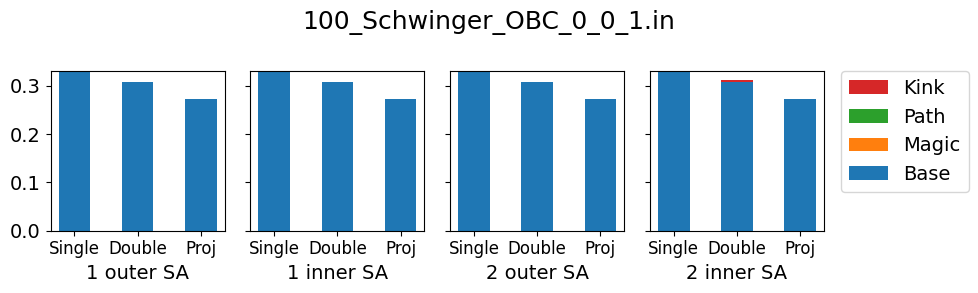

Decreasing: 2 outer SA Yes Kink ['Single'] 1.7587365236826358e-05


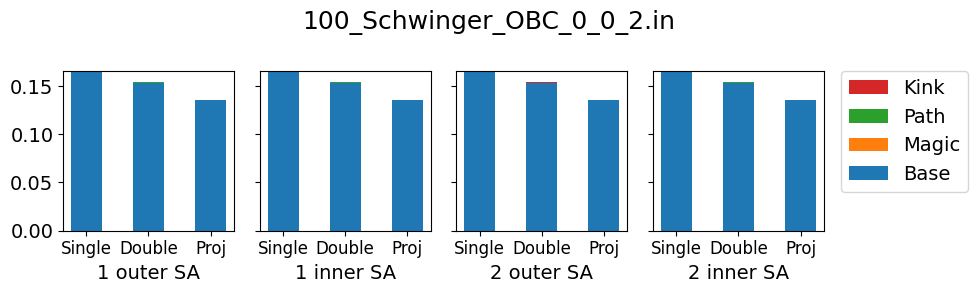

Decreasing: 2 inner SA Yes Kink ['Proj'] 1.7469384902948915e-05


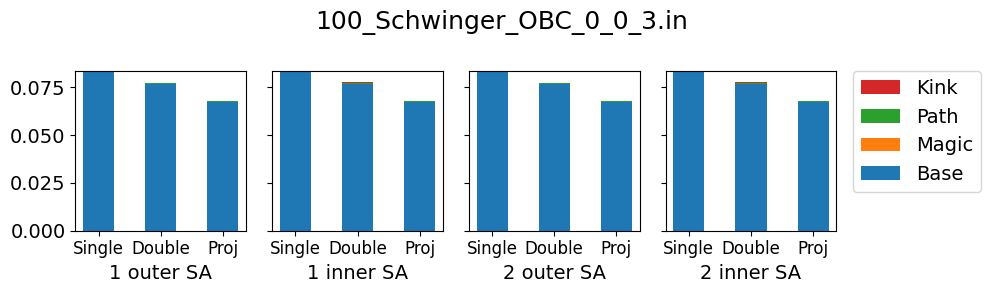

Decreasing: 2 outer SA Yes Kink ['Single'] 1.724048756098634e-05


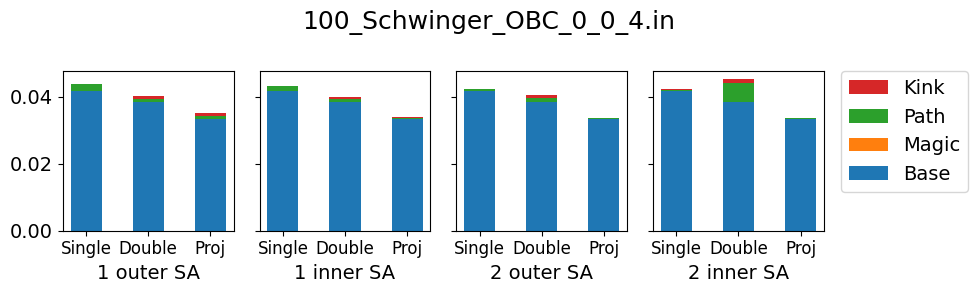

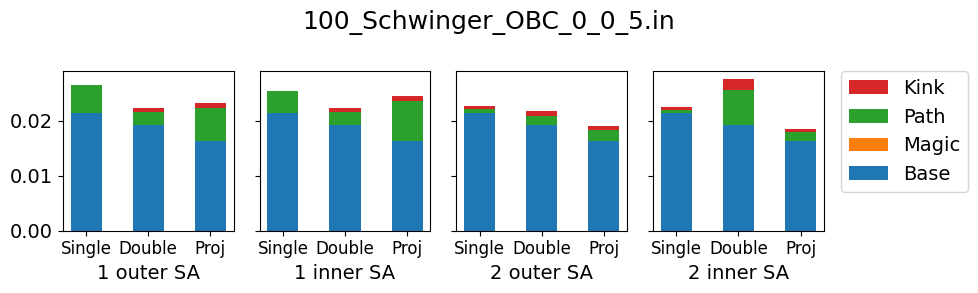

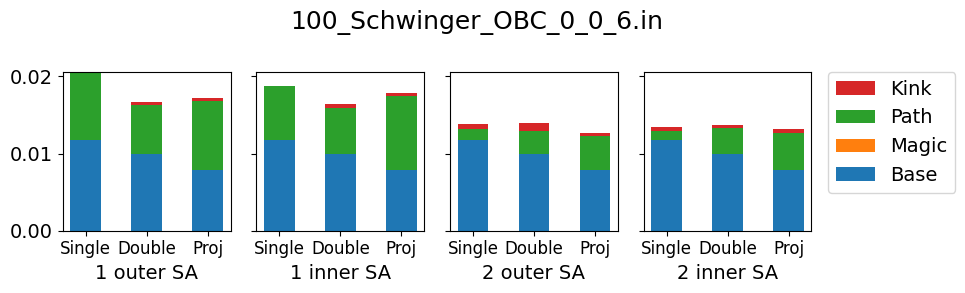

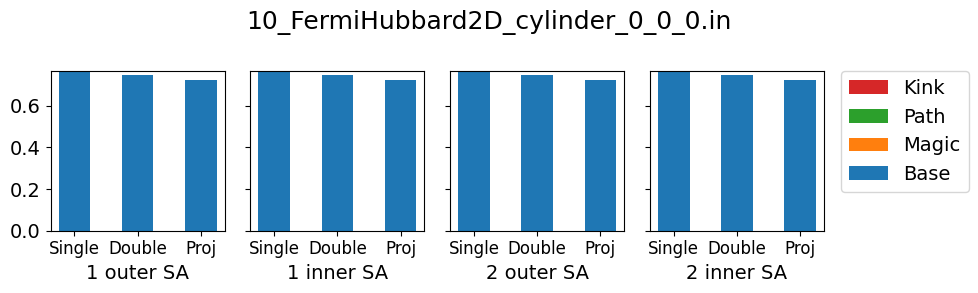

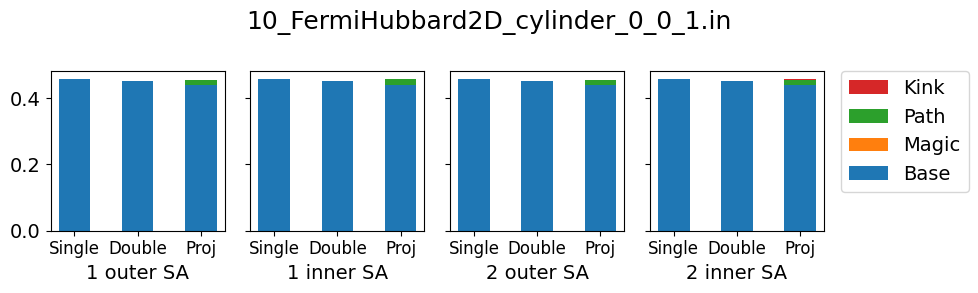

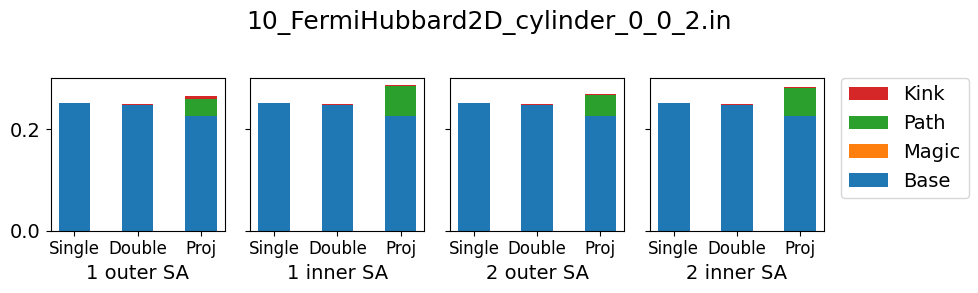

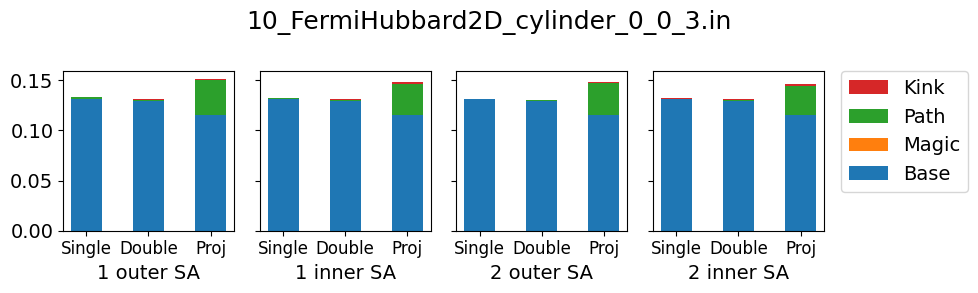

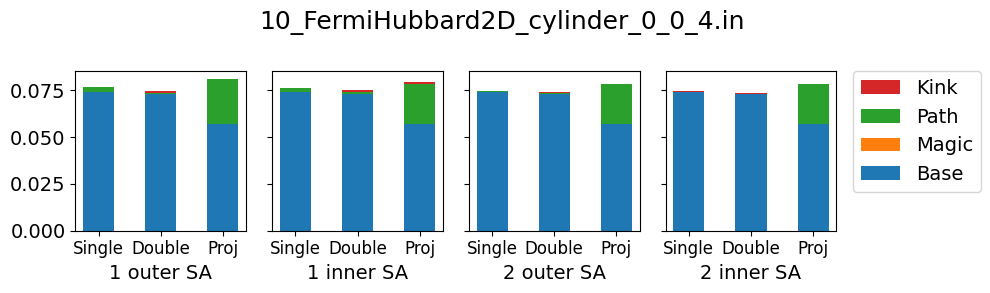

Decreasing: 1 inner SA Yes Kink ['Proj'] 8.168599901980933e-05


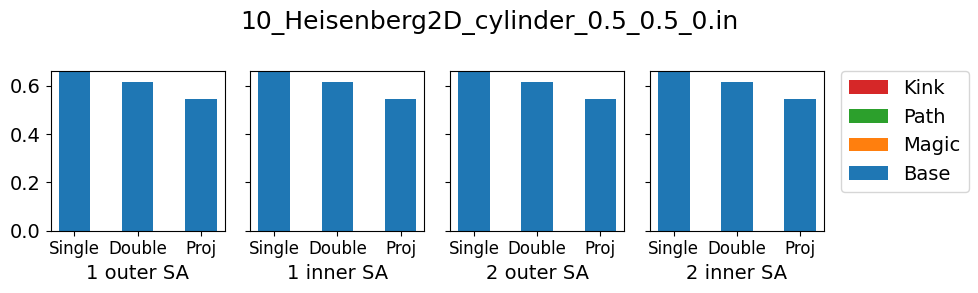

Decreasing: 2 inner SA Yes Kink ['Proj'] 8.120838070485581e-05


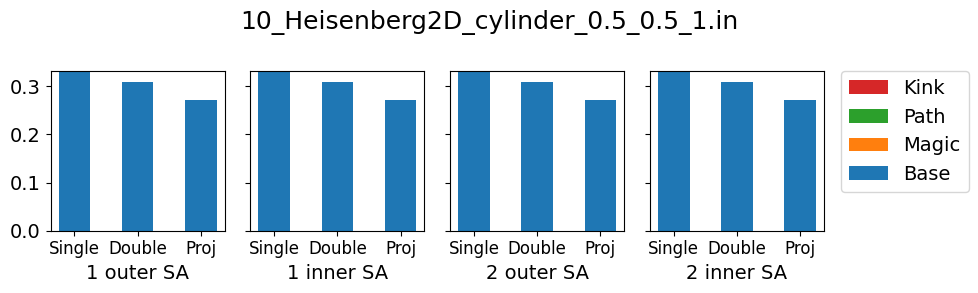

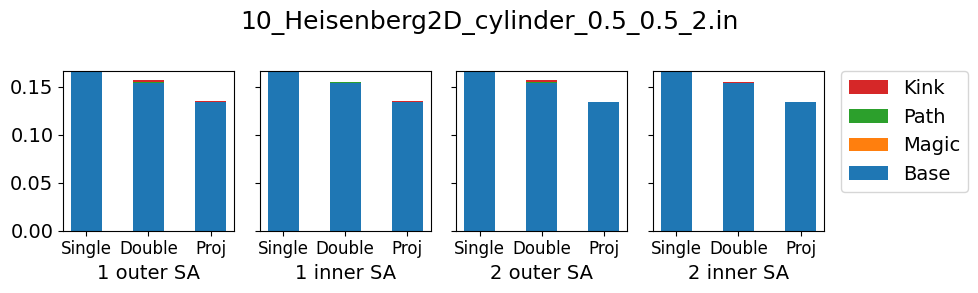

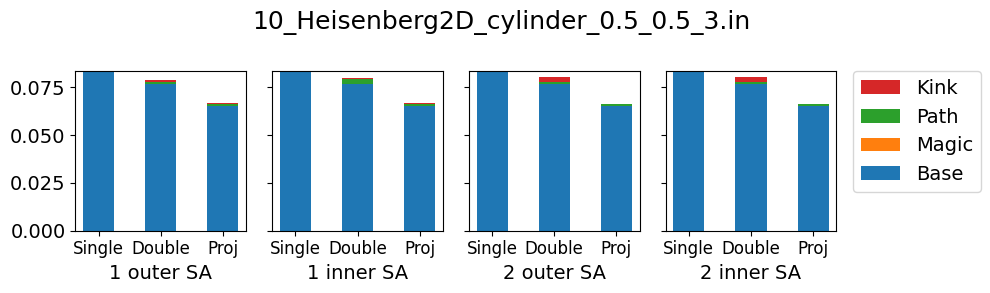

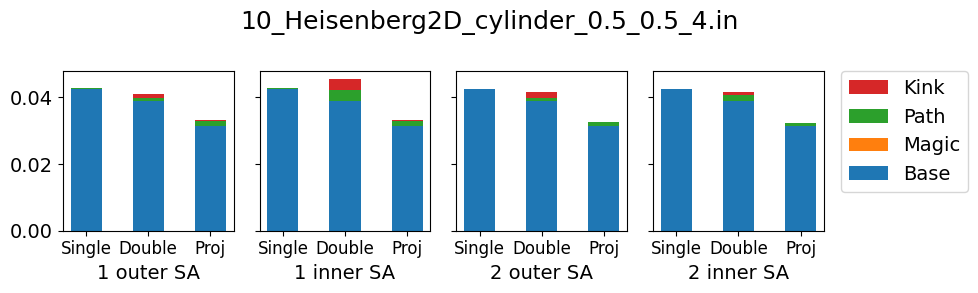

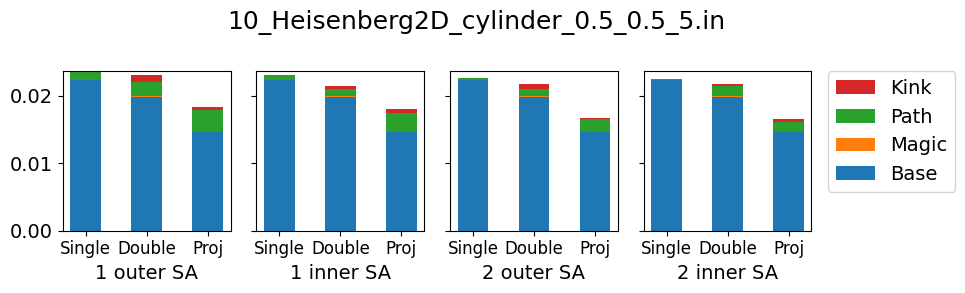

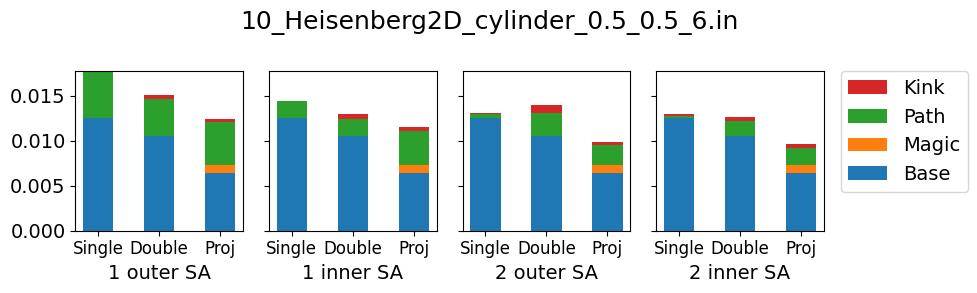

Decreasing: 2 inner SA Yes Kink ['Proj'] 0.00030156815440285367


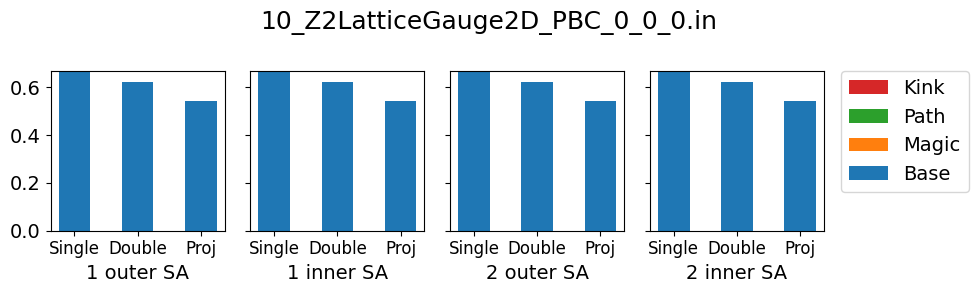

Decreasing: 1 outer SA Yes Kink ['Proj'] 0.0002969121140142805


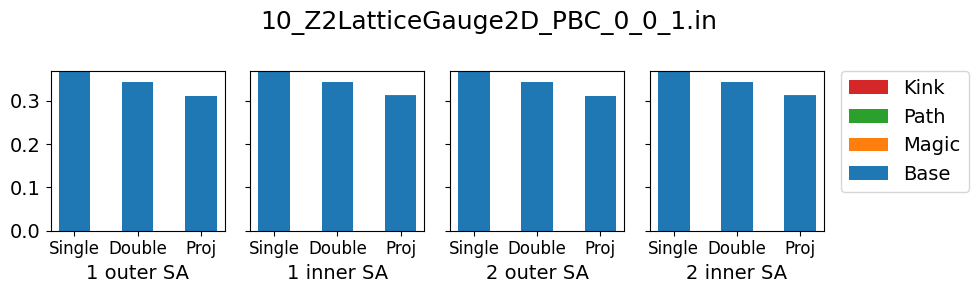

Decreasing: 2 outer SA Yes Kink ['Proj'] 0.0002849002849003024


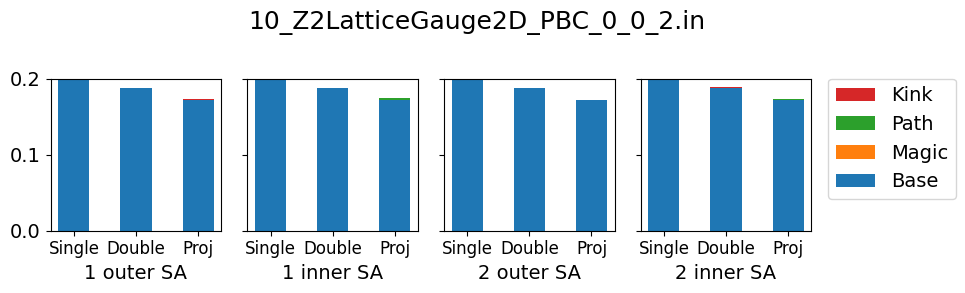

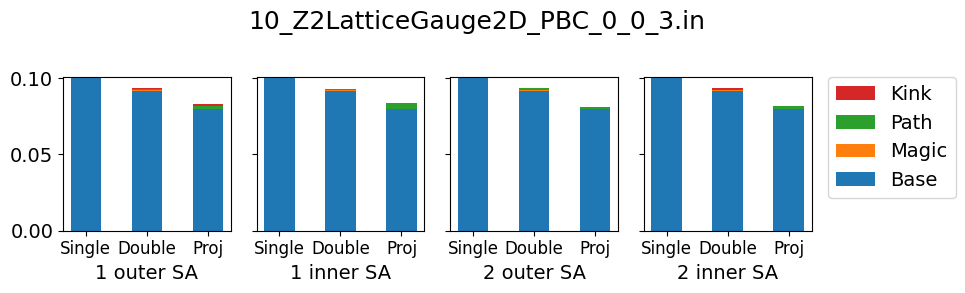

Decreasing: 1 inner SA Yes Kink ['Double'] 0.00023419203747072903


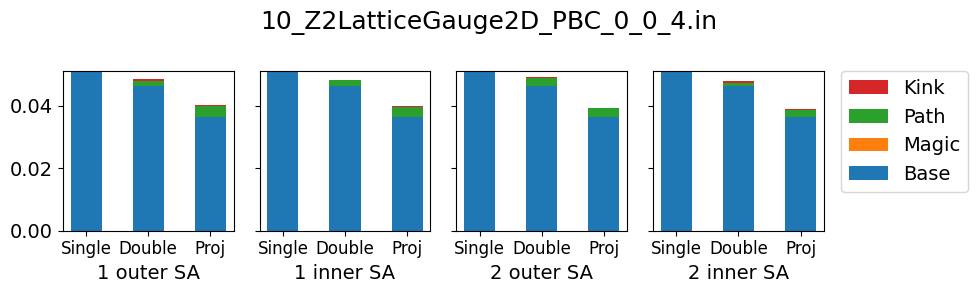

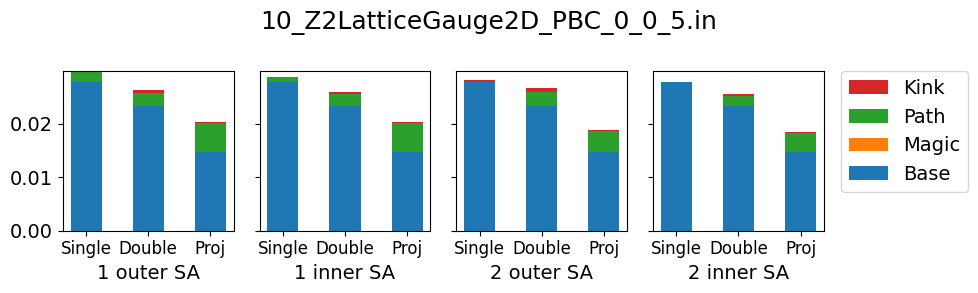

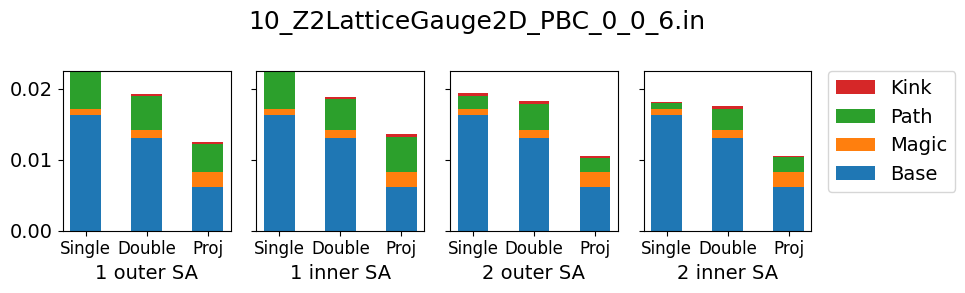

In [7]:
analyze("../../out/table/table_time_20250525_1619.txt", "circuit-wise", True)

### Circuit volume

result_SELECT_100_Heisenberg1D_OBC_1_0 Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')


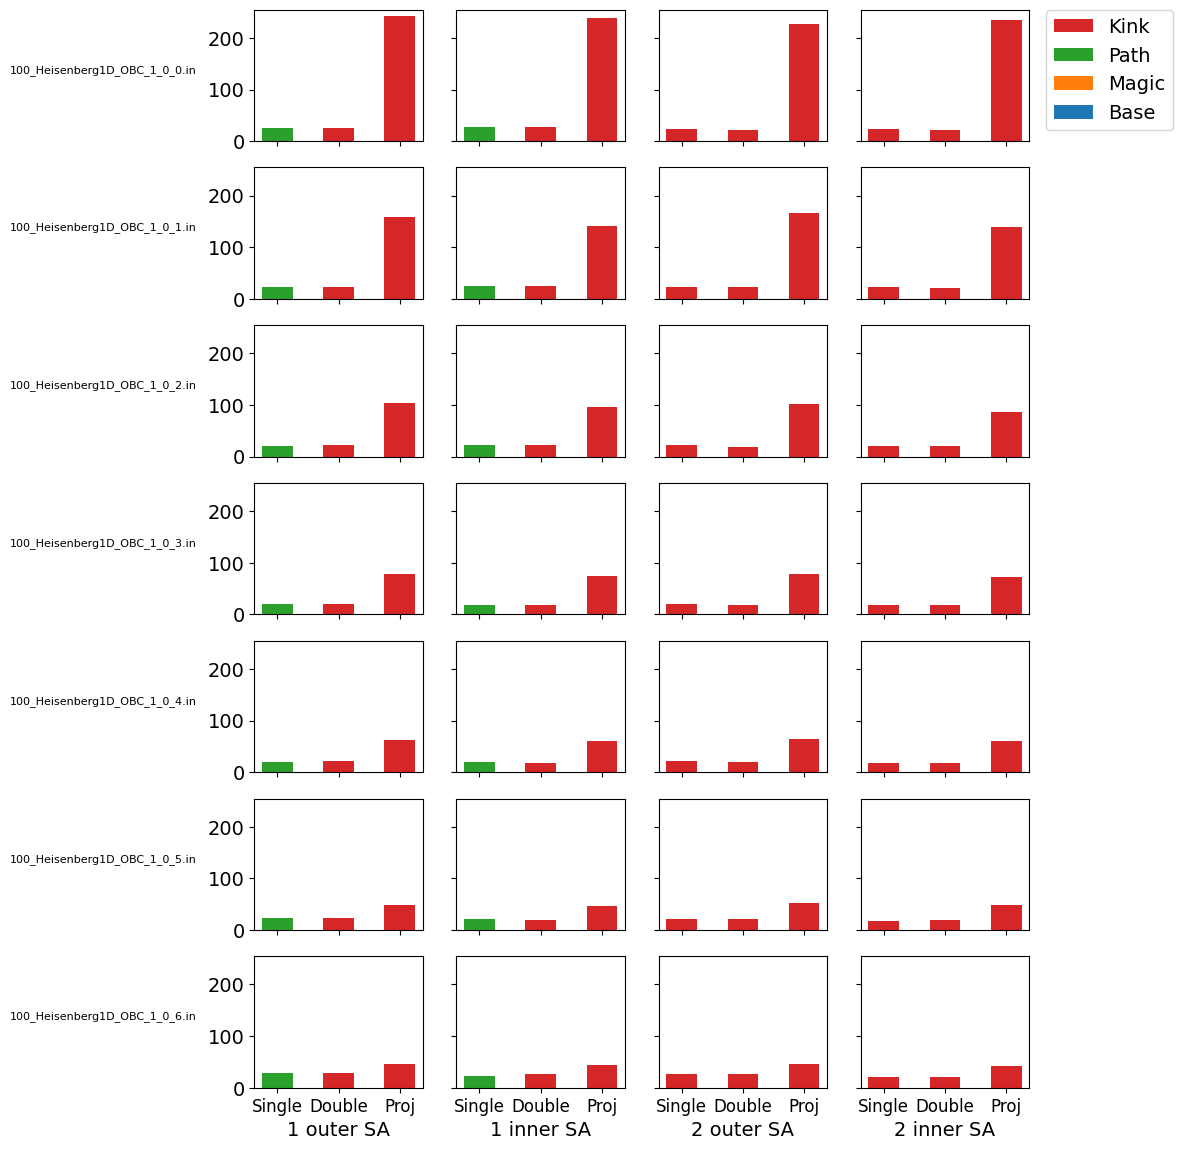

result_SELECT_100_Schwinger_OBC_0_0 Int64Index([7, 8, 9, 10, 11, 12, 13], dtype='int64')


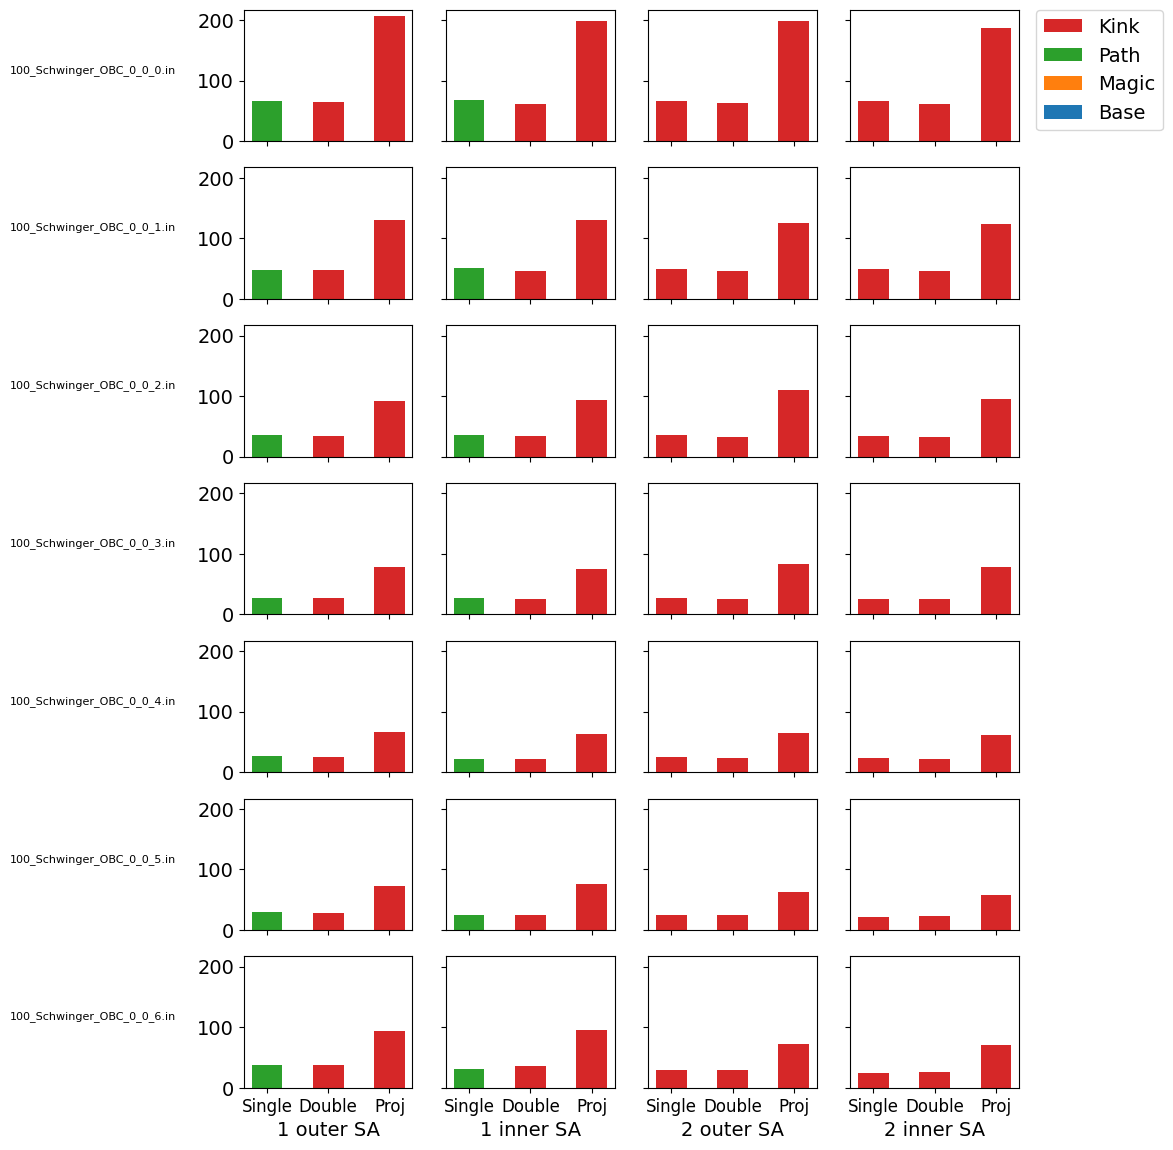

result_SELECT_10_FermiHubbard2D_cylinder_0_0 Int64Index([14, 15, 16, 17, 18], dtype='int64')


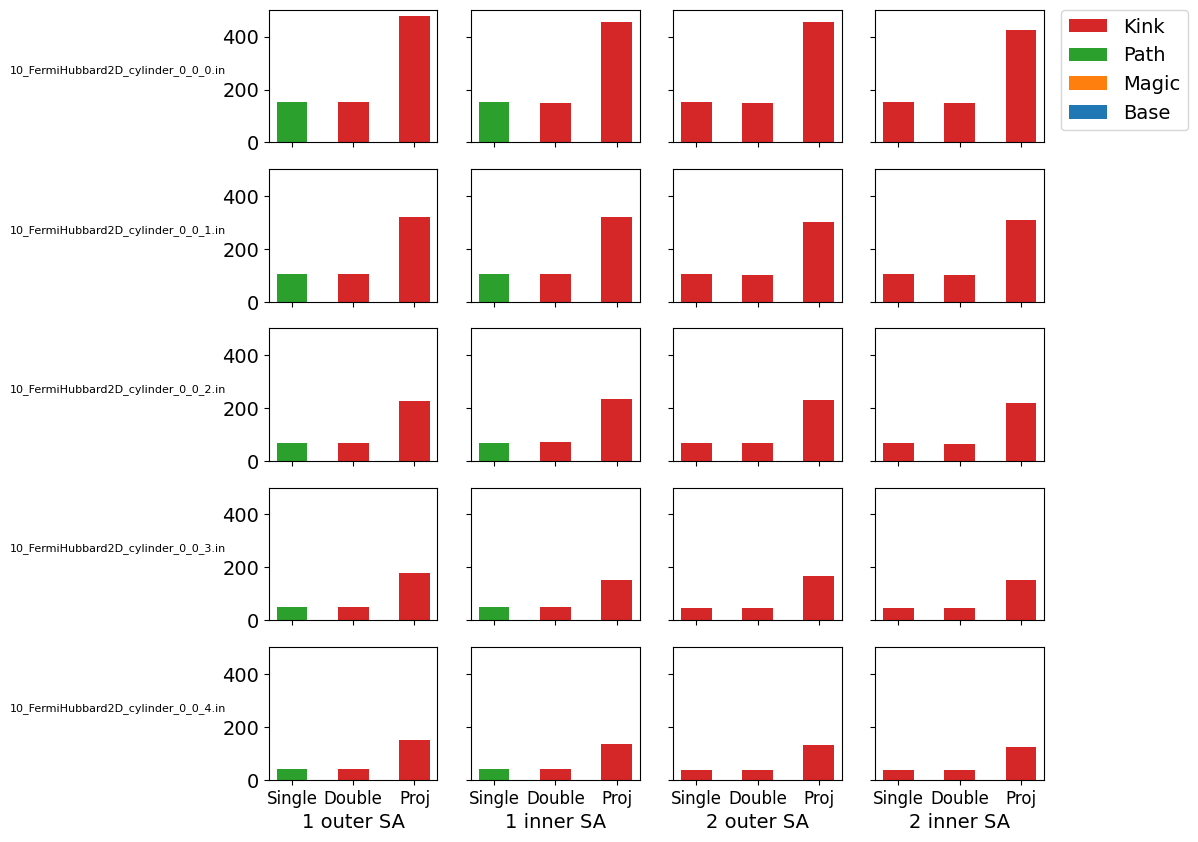

result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5 Int64Index([19, 20, 21, 22, 23, 24, 25], dtype='int64')


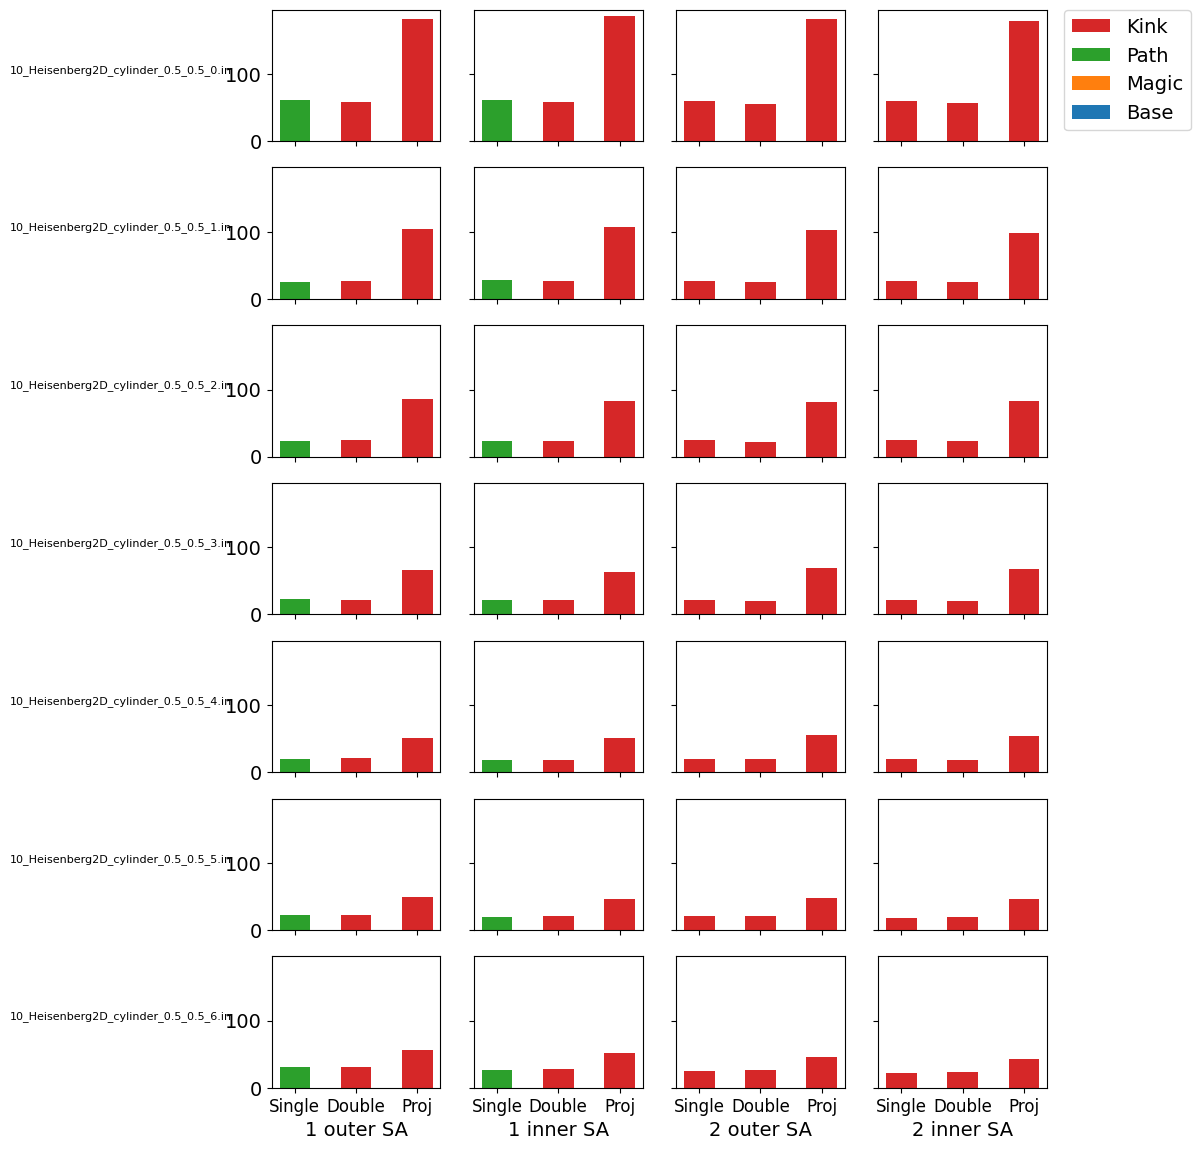

result_SELECT_10_Z2LatticeGauge2D_PBC_0_0 Int64Index([26, 27, 28, 29, 30, 31, 32], dtype='int64')


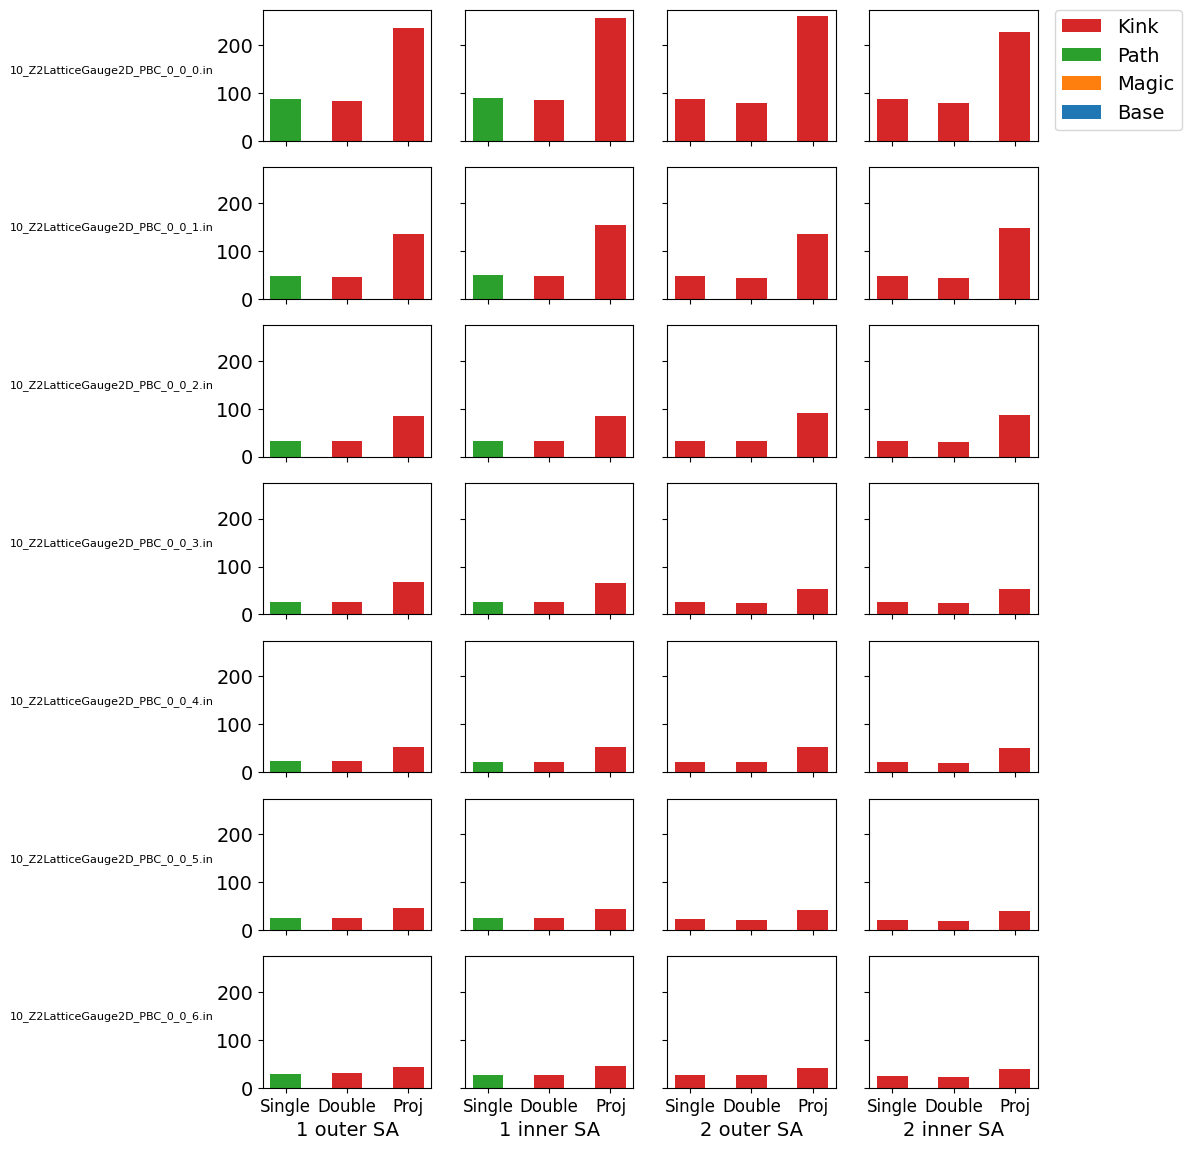

In [8]:
analyze("../../out/table/table_volume_20250602_0906.txt", "group-wise", True)